In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Libraries imported!')

Libraries imported!


In [ ]:
# Load data
df = pd.read_csv('fraud_detection_dashboard_data.csv')
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print(f'Total rows     : {len(df):,}')
print(f'Fraud rows     : {len(fraud):,}')
print(f'Legitimate rows: {len(legit):,}')
print(f'\nAmount Statistics:')
print(f'Avg Legitimate : ${legit.mean():.2f}')
print(f'Avg Fraud      : ${fraud.mean():.2f}')
print(f'Max Legitimate : ${legit.max():.2f}')
print(f'Max Fraud      : ${fraud.max():.2f}')

Total rows     : 28,372
Fraud rows     : 47
Legitimate rows: 28,325

Amount Statistics:
Avg Legitimate : $88.24
Avg Fraud      : $104.27
Max Legitimate : $7712.43
Max Fraud      : $730.86


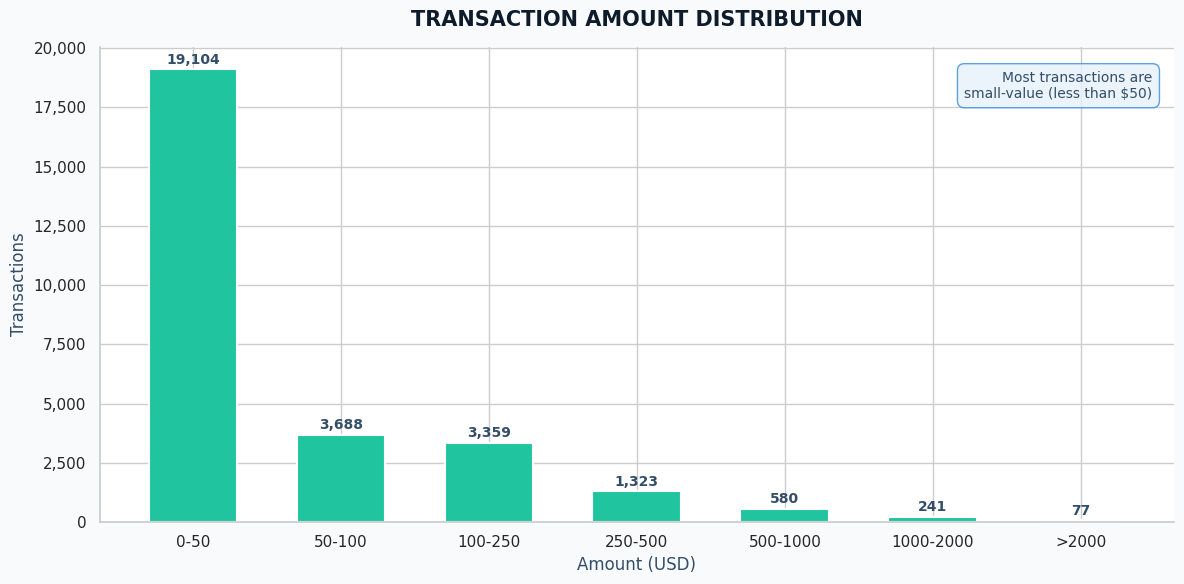

Saved: amount_bucket_distribution.png


In [11]:
# ── CHART 1: Amount Bucket Distribution ──

# Create buckets 
bins   = [-0.01, 50, 100, 250, 500, 1000, 2000, np.inf]
labels = ['0-50', '50-100', '100-250', '250-500',
          '500-1000', '1000-2000', '>2000']

df['Amount_Bucket'] = pd.cut(df['Amount'], bins=bins, labels=labels)
bucket_counts = df['Amount_Bucket'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#FFFFFF')

bars = ax.bar(
    labels, bucket_counts.values,
    color='#20C5A0',
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

# Data labels on bars
for bar, val in zip(bars, bucket_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{int(val):,}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#334E68'
    )

ax.set_title('TRANSACTION AMOUNT DISTRIBUTION',
             fontsize=15, fontweight='bold',
             color='#0D1B2A', pad=15)
ax.set_xlabel('Amount (USD)', fontsize=12, color='#334E68')
ax.set_ylabel('Transactions', fontsize=12, color='#334E68')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.spines[['top','right']].set_visible(False)

# Insight text box
ax.text(0.98, 0.95,
        'Most transactions are\nsmall-value (less than $50)',
        transform=ax.transAxes,
        fontsize=10, color='#334E68',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='#E6F1FB',
                  edgecolor='#378ADD',
                  alpha=0.8))

plt.tight_layout()
plt.savefig('amount_bucket_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved: amount_bucket_distribution.png')

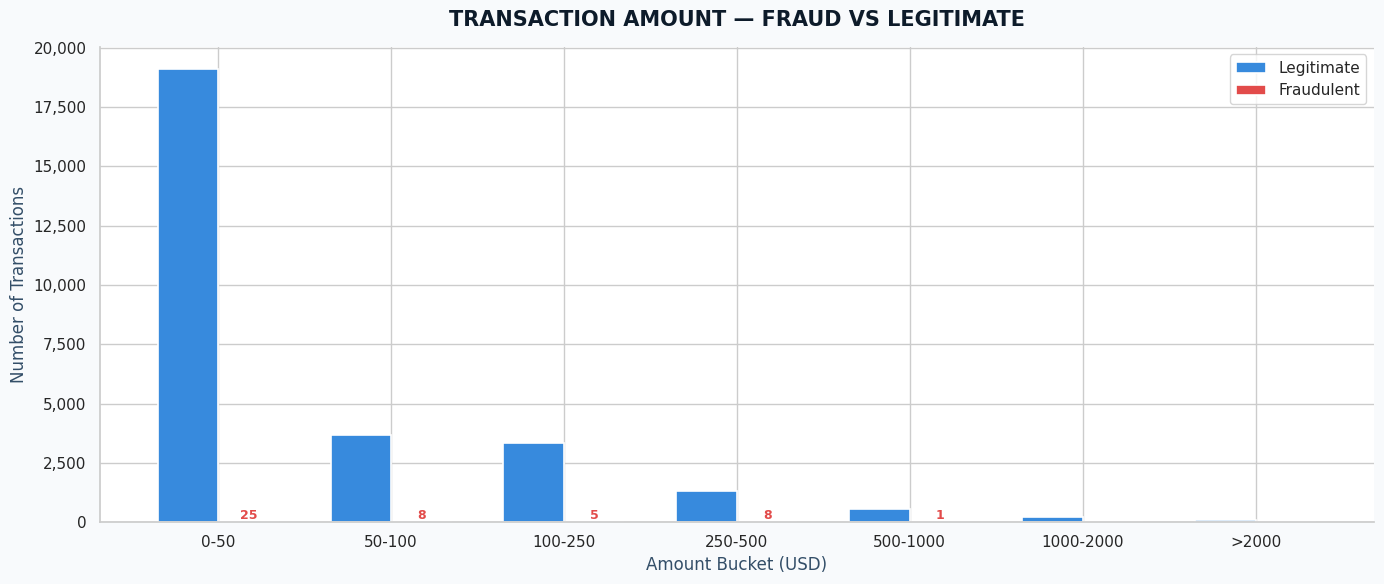

Saved: amount_fraud_vs_legit.png


In [10]:
# ── CHART 2: Fraud vs Legitimate Amount Comparison ──

fraud_buckets = pd.cut(fraud, bins=bins, labels=labels).value_counts().reindex(labels)
legit_buckets = pd.cut(legit, bins=bins, labels=labels).value_counts().reindex(labels)

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#FFFFFF')

bars1 = ax.bar(x - width/2, legit_buckets.values,
               width, label='Legitimate',
               color='#378ADD', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, fraud_buckets.values,
               width, label='Fraudulent',
               color='#E24B4A', edgecolor='white', linewidth=1.2)

# Data labels
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{int(bar.get_height())}',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#E24B4A')

ax.set_title('TRANSACTION AMOUNT — FRAUD VS LEGITIMATE',
             fontsize=15, fontweight='bold',
             color='#0D1B2A', pad=15)
ax.set_xlabel('Amount Bucket (USD)', fontsize=12, color='#334E68')
ax.set_ylabel('Number of Transactions', fontsize=12, color='#334E68')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('amount_fraud_vs_legit.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved: amount_fraud_vs_legit.png')

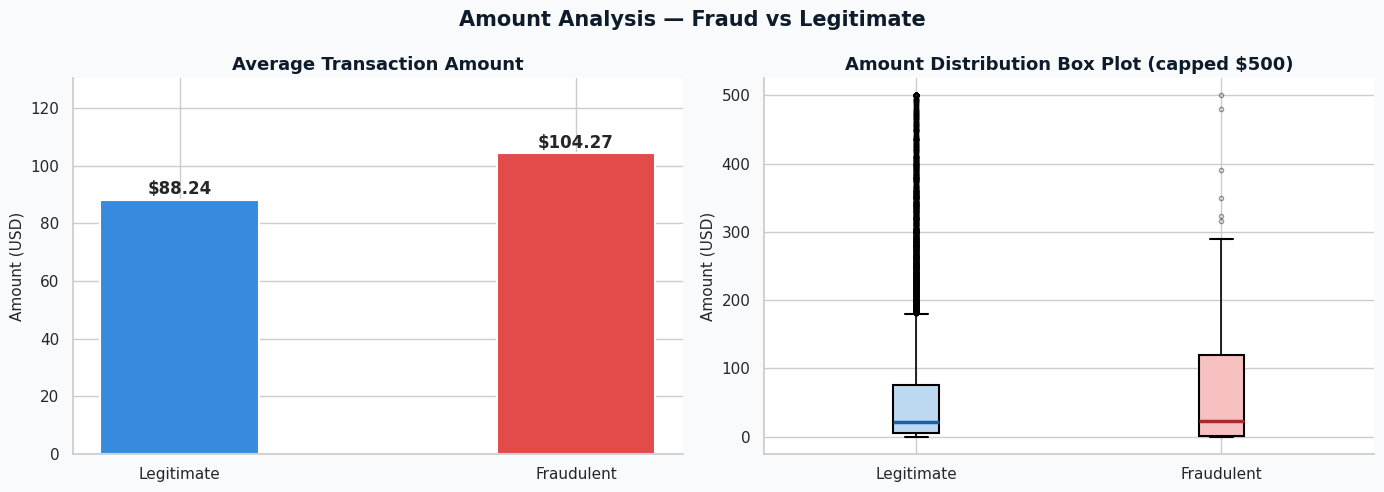

Saved: amount_comparison.png


In [9]:
# ── CHART 3: Average Amount Comparison (Clean Bar) ──

avg_amounts = [legit.mean(), fraud.mean()]
labels_avg  = ['Legitimate', 'Fraudulent']
colors_avg  = ['#378ADD', '#E24B4A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8FAFC')

# Left — Avg Amount Bar
axes[0].set_facecolor('#FFFFFF')
bars = axes[0].bar(labels_avg, avg_amounts,
                   color=colors_avg, width=0.4,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, avg_amounts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'${val:.2f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )
axes[0].set_title('Average Transaction Amount',
                   fontsize=13, fontweight='bold', color='#0D1B2A')
axes[0].set_ylabel('Amount (USD)', fontsize=11)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_ylim(0, max(avg_amounts) * 1.25)

# Right — Box Plot
axes[1].set_facecolor('#FFFFFF')
bp = axes[1].boxplot(
    [legit.clip(upper=500), fraud.clip(upper=500)],
    labels=['Legitimate', 'Fraudulent'],
    patch_artist=True,
    boxprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
bp['boxes'][0].set_facecolor('#BDD9F2')
bp['boxes'][1].set_facecolor('#F7C1C1')
bp['medians'][0].set_color('#185FA5')
bp['medians'][1].set_color('#A32D2D')
axes[1].set_title('Amount Distribution Box Plot (capped $500)',
                   fontsize=13, fontweight='bold', color='#0D1B2A')
axes[1].set_ylabel('Amount (USD)', fontsize=11)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Amount Analysis — Fraud vs Legitimate',
             fontsize=15, fontweight='bold', color='#0D1B2A')
plt.tight_layout()
plt.savefig('amount_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#F8FAFC')
plt.show()
print('Saved: amount_comparison.png')